# Week 5 — Business Analytics Case Study
### Bank Marketing (Term Deposit Subscription)

**Business Problem:** Why do some clients subscribe to a term deposit while others do not, and which customer segments respond best to marketing campaigns?


## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

## 2. Load the Dataset

If you're on **Google Colab**, run the upload cell below first. If you're on **local Jupyter**, just make sure the CSV is in the same folder.


In [ ]:
df = pd.read_csv("bank.csv", sep=",")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## 3. Dataset Understanding

In [ ]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)

Shape: (11162, 17)

Data types:
 age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object


In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print("Numerical features:", numerical_cols)
print("Categorical features:", categorical_cols)

Numerical features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


In [ ]:
# Target variable distribution
df["deposit"].value_counts(normalize=True) * 100

,proportion
deposit,
no,52.616019
yes,47.383981


## 4. Data Cleaning



In [ ]:
# Check for 'unknown' placeholders
for col in categorical_cols:
    n_unknown = (df[col] == "unknown").sum()
    if n_unknown > 0:
        print(f"{col}: {n_unknown} unknown values ({n_unknown/len(df)*100:.1f}%)")

job: 70 unknown values (0.6%)
education: 497 unknown values (4.5%)
contact: 2346 unknown values (21.0%)
poutcome: 8326 unknown values (74.6%)


In [ ]:
# Check for true nulls and duplicates
print("Null values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Null values per column:
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Duplicate rows: 0


In [ ]:
df_clean = df.copy()

# Drop exact duplicate rows if any
df_clean = df_clean.drop_duplicates()

# Standardize text columns to lowercase for consistency
for col in categorical_cols:
    df_clean[col] = df_clean[col].str.strip().str.lower()

df_clean.shape

(11162, 17)

In [ ]:
# Basic outlier check on 'balance' and 'duration'
df_clean[["balance", "duration", "age"]].describe()

,balance,duration,age
count,11162.000000,11162.000000,11162.000000
mean,1528.538524,371.993818,41.231948
std,3225.413326,347.128386,11.913369
min,-6847.000000,2.000000,18.000000
25%,122.000000,138.000000,32.000000
50%,550.000000,255.000000,39.000000
75%,1708.000000,496.000000,49.000000
max,81204.000000,3881.000000,95.000000


## 5. Summary Statistics

In [ ]:
df_clean[numerical_cols].agg(["mean", "median", "min", "max", "std"]).T

,mean,median,min,max,std
age,41.231948,39.0,18.0,95.0,11.913369
balance,1528.538524,550.0,-6847.0,81204.0,3225.413326
day,15.658036,15.0,1.0,31.0,8.420740
duration,371.993818,255.0,2.0,3881.0,347.128386
campaign,2.508421,2.0,1.0,63.0,2.722077
pdays,51.330407,-1.0,-1.0,854.0,108.758282
previous,0.832557,0.0,0.0,58.0,2.292007


## 6. Exploratory Data Analysis — Key Drivers

### 6.1 Correlation Heatmap (numeric features)

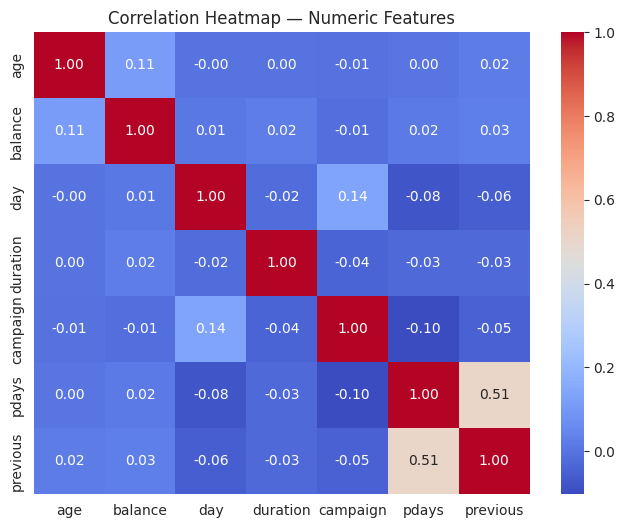

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[numerical_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap — Numeric Features")
plt.show()

### 6.2 Subscription Rate by Job Type

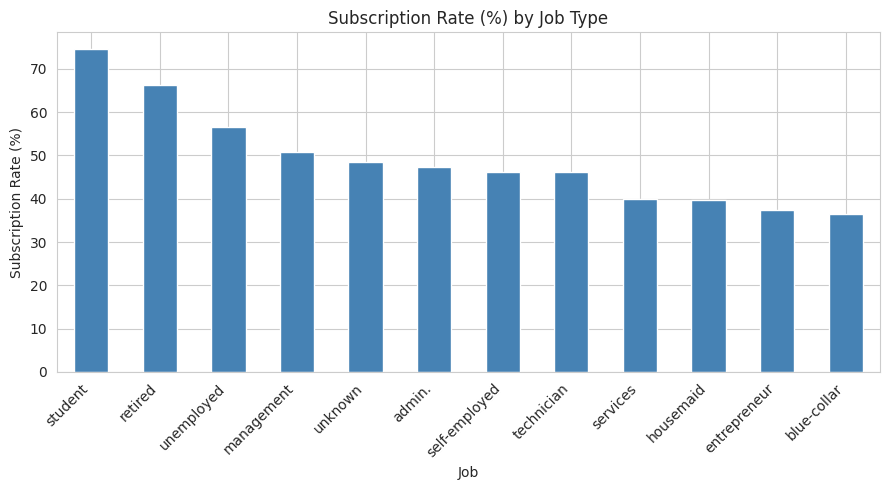

In [ ]:
job_rate = df_clean.groupby("job")["deposit"].apply(lambda x: (x == "yes").mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
job_rate.plot(kind="bar", color="steelblue")
plt.title("Subscription Rate (%) by Job Type")
plt.ylabel("Subscription Rate (%)")
plt.xlabel("Job")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 6.3 Subscription Rate by Education Level

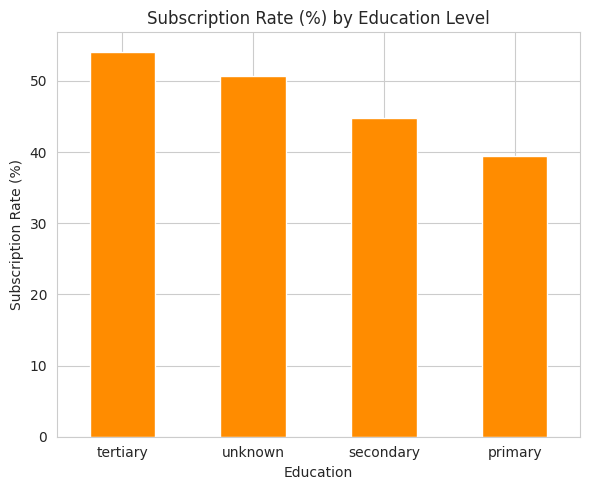

In [ ]:
edu_rate = df_clean.groupby("education")["deposit"].apply(lambda x: (x == "yes").mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(6, 5))
edu_rate.plot(kind="bar", color="darkorange")
plt.title("Subscription Rate (%) by Education Level")
plt.ylabel("Subscription Rate (%)")
plt.xlabel("Education")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 6.4 Subscription Rate by Marital Status

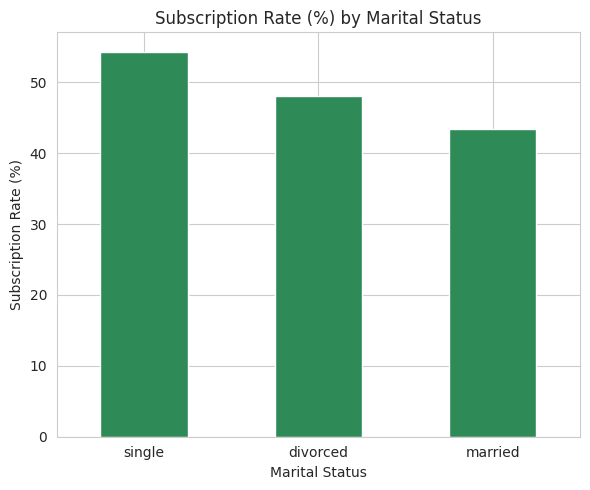

In [ ]:
marital_rate = df_clean.groupby("marital")["deposit"].apply(lambda x: (x == "yes").mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(6, 5))
marital_rate.plot(kind="bar", color="seagreen")
plt.title("Subscription Rate (%) by Marital Status")
plt.ylabel("Subscription Rate (%)")
plt.xlabel("Marital Status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 6.5 Subscription Rate by Contact Method

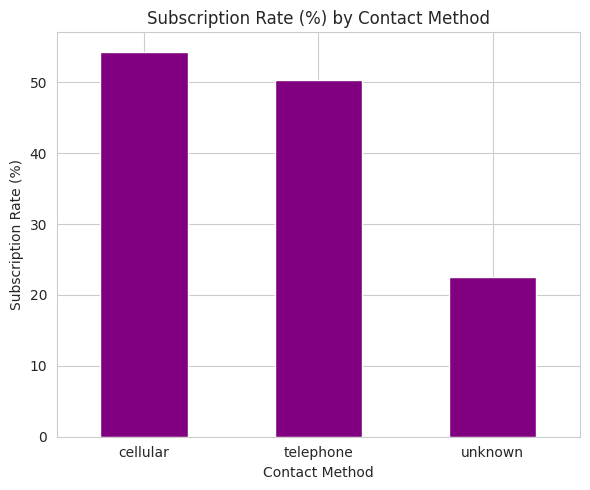

In [ ]:
contact_rate = df_clean.groupby("contact")["deposit"].apply(lambda x: (x == "yes").mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(6, 5))
contact_rate.plot(kind="bar", color="purple")
plt.title("Subscription Rate (%) by Contact Method")
plt.ylabel("Subscription Rate (%)")
plt.xlabel("Contact Method")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 6.6 Effect of Previous Campaign Outcome (poutcome)

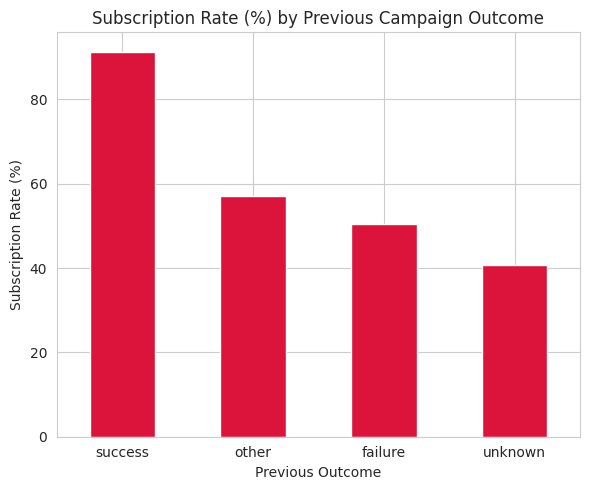

In [ ]:
poutcome_rate = df_clean.groupby("poutcome")["deposit"].apply(lambda x: (x == "yes").mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(6, 5))
poutcome_rate.plot(kind="bar", color="crimson")
plt.title("Subscription Rate (%) by Previous Campaign Outcome")
plt.ylabel("Subscription Rate (%)")
plt.xlabel("Previous Outcome")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 6.7 Call Duration vs Subscription

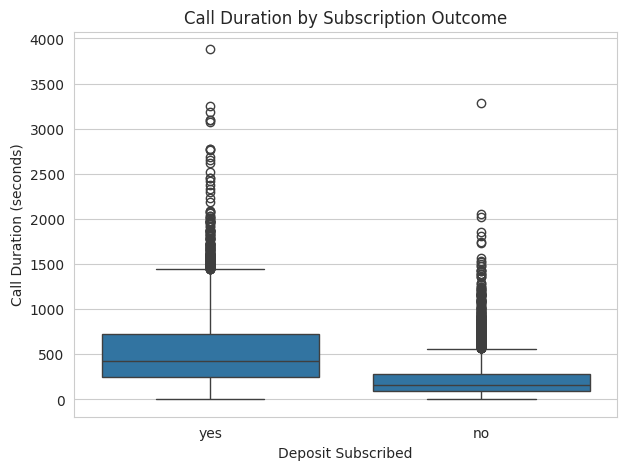

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_clean, x="deposit", y="duration")
plt.title("Call Duration by Subscription Outcome")
plt.xlabel("Deposit Subscribed")
plt.ylabel("Call Duration (seconds)")
plt.show()

### 6.8 Subscription Rate by Month of Contact

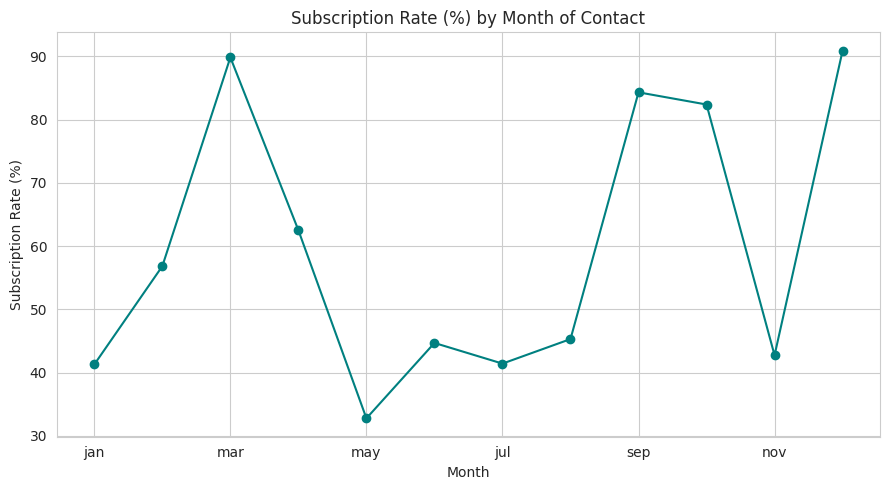

In [ ]:
month_order = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
month_rate = df_clean.groupby("month")["deposit"].apply(lambda x: (x == "yes").mean() * 100).reindex(month_order)

plt.figure(figsize=(9, 5))
month_rate.plot(kind="line", marker="o", color="teal")
plt.title("Subscription Rate (%) by Month of Contact")
plt.ylabel("Subscription Rate (%)")
plt.xlabel("Month")
plt.tight_layout()
plt.show()